# Customer Churn Prediction

## Contexto
O cancelamento de assinaturas ocorre quando os clientes param de usar o serviço de uma empresa, para empresas com modelos de negócios baseados em assinaturas (telecomunicações, streaming, saas) o cancelamento impacta diretamente a receita.

## Objetivo
Usando Machine Learning, vamos prever quais clientes têm mais probabilidade de cancelar serviços e assim, permitir que a empresa tome medidas preventivas.

## Autoria
Wellington M. Santos
- **Linkedin**: [in/wellington-moreira-santos](https://www.linkedin.com/in/wellington-moreira-santos/)
- **Github**: [esscova](https://github.com/esscova)

## Fluxo deste notebook
1. Preprocessing
2. Model training
3. Model evaluation
4. Model comparison
5. Business insights
6. Model export

## 1. DEPENDÊNCIAS E CONFIGURAÇÕES

In [2]:
# diretorio
from pathlib import Path

# data manipulation
import pandas as pd
import numpy as np

# dataviz
import matplotlib.pyplot as plt
import seaborn as sns

# machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# machine learning models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

# save trained models
import joblib

## 2. CARREGANDO DATASET

In [3]:
# preprocessed
df = pd.read_parquet(Path.cwd().parent/'data/preprocessed.parquet')
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgCharges,NewCustomer
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,14.925000,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,No,53.985714,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,36.050000,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,40.016304,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,50.550000,1


## 3. PREPROCESSING

### 3.1. Encoding

In [4]:
# ENCODING QUALITATIVOS
encoders = {}

for col in df.columns:
    if df[col].dtype == "object":

        le = LabelEncoder()

        df[col] = le.fit_transform(df[col])

        encoders[col] = le

In [5]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgCharges,NewCustomer
0,0,0,1,0,1,0,1,0,0,2,...,0,0,0,1,2,29.85,29.85,0,14.925000,1
1,1,0,0,0,34,1,0,0,2,0,...,0,0,1,0,3,56.95,1889.50,0,53.985714,0
2,1,0,0,0,2,1,0,0,2,2,...,0,0,0,1,3,53.85,108.15,1,36.050000,1
3,1,0,0,0,45,0,1,0,2,0,...,0,0,1,0,0,42.30,1840.75,0,40.016304,0
4,0,0,0,0,2,1,0,1,0,0,...,0,0,0,1,2,70.70,151.65,1,50.550000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,...,2,2,1,1,3,84.80,1990.50,0,79.620000,0
7039,0,0,1,1,72,1,2,1,0,2,...,2,2,1,1,1,103.20,7362.90,0,100.861644,0
7040,0,0,1,1,11,0,1,0,2,0,...,0,0,0,1,2,29.60,346.45,0,28.870833,1
7041,1,1,1,0,4,1,2,1,0,0,...,0,0,0,1,3,74.40,306.60,1,61.320000,1


### 3.2. Split features

In [6]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [7]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,AvgCharges,NewCustomer
0,0,0,1,0,1,0,1,0,0,2,...,0,0,0,0,1,2,29.85,29.85,14.925000,1
1,1,0,0,0,34,1,0,0,2,0,...,0,0,0,1,0,3,56.95,1889.50,53.985714,0
2,1,0,0,0,2,1,0,0,2,2,...,0,0,0,0,1,3,53.85,108.15,36.050000,1
3,1,0,0,0,45,0,1,0,2,0,...,2,0,0,1,0,0,42.30,1840.75,40.016304,0
4,0,0,0,0,2,1,0,1,0,0,...,0,0,0,0,1,2,70.70,151.65,50.550000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,...,2,2,2,1,1,3,84.80,1990.50,79.620000,0
7039,0,0,1,1,72,1,2,1,0,2,...,0,2,2,1,1,1,103.20,7362.90,100.861644,0
7040,0,0,1,1,11,0,1,0,2,0,...,0,0,0,0,1,2,29.60,346.45,28.870833,1
7041,1,1,1,0,4,1,2,1,0,0,...,0,0,0,0,1,3,74.40,306.60,61.320000,1


In [8]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [9]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
X_train.shape, y_train.shape

((5634, 21), (5634,))

In [11]:
X_test.shape, y_test.shape

((1409, 21), (1409,))

### 3.3. Scaling

In [12]:
# scaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
X_train

array([[-1.02516569, -0.4377492 , -0.96957859, ..., -0.42134513,
        -0.01422481, -0.64217136],
       [-1.02516569, -0.4377492 , -0.96957859, ...,  1.25588791,
         0.49310492, -0.64217136],
       [ 0.97545208, -0.4377492 ,  1.03137591, ..., -1.00215117,
        -0.77974648,  1.55721675],
       ...,
       [ 0.97545208, -0.4377492 ,  1.03137591, ..., -0.87717627,
        -0.59527142, -0.64217136],
       [ 0.97545208,  2.28441306, -0.96957859, ..., -0.4817762 ,
         0.47837639, -0.64217136],
       [ 0.97545208, -0.4377492 , -0.96957859, ..., -0.8102886 ,
        -0.69838354, -0.64217136]])

## 4. MODEL TRAINING

### 4.1. Baseline

In [14]:
# train
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)

# pred
baseline_pred = baseline.predict(X_test)

# evaluation
print(f'Baseline accuracy: {accuracy_score(y_test, baseline_pred):.2%} ')

Baseline accuracy: 73.53% 


### 4.2. Logistic Regression 

In [15]:
# train
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# pred
pred_log = log_model.predict(X_test)
pred_log

array([1, 0, 0, ..., 0, 0, 1])

### 4.3. Random Forest

In [16]:
# train
rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)

# preds
pred_rf = rf_model.predict(X_test)
pred_rf

array([1, 0, 0, ..., 0, 0, 1])

## 5. MODEL EVALUATION

### 5.1. Logistic Regression

In [17]:
print(f'Logistic Regression Accuracy: {accuracy_score(y_test, pred_log):.2%}')
print()
print(classification_report(y_test, pred_log))

Logistic Regression Accuracy: 81.05%

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1036
           1       0.67      0.55      0.61       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



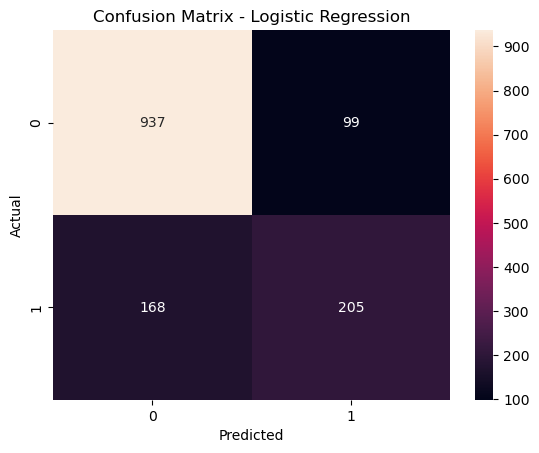

In [18]:
# CM
cm_log = confusion_matrix(y_test, pred_log)

sns.heatmap(cm_log, annot=True, fmt='d')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [22]:
# ROC AUC
log_probs = log_model.predict_proba(X_test)[:,1]
log_probs

array([0.66362314, 0.08628339, 0.00646664, ..., 0.03832493, 0.02469868,
       0.58967846])

In [33]:
fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
fpr_log[:5], tpr_log[:5]

(array([0.        , 0.        , 0.        , 0.00096525, 0.00096525]),
 array([0.        , 0.00268097, 0.03485255, 0.03485255, 0.03753351]))

In [34]:
roc_auc_log = auc(fpr_log, tpr_log)
roc_auc_log

np.float64(0.8616883352138044)

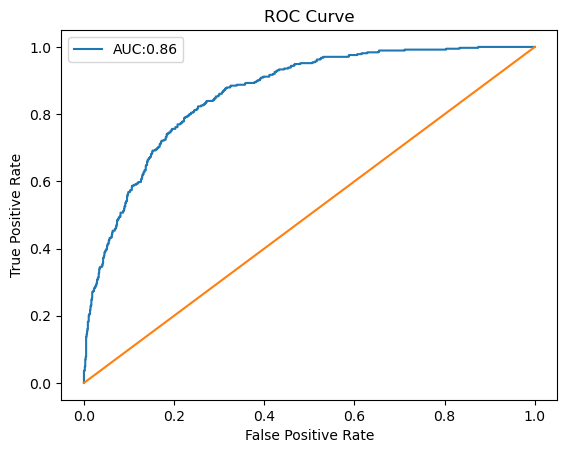

In [35]:
plt.plot(fpr_log, tpr_log, label=f'AUC:{roc_auc_log:.2f}')
plt.plot([0,1],[0,1])
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

### 5.2. Random Forest

In [19]:
print(f'Random Forest Accuracy: {accuracy_score(y_test, pred_rf):.2%}')
print()
print(classification_report(y_test, pred_rf))

Random Forest Accuracy: 79.63%

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1036
           1       0.65      0.50      0.56       373

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.80      0.79      1409



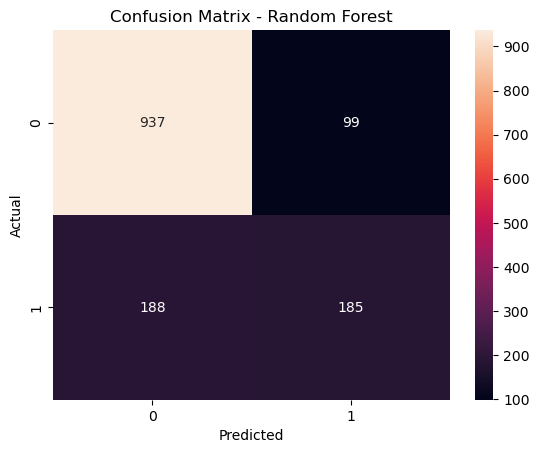

In [20]:
# CM
cm_rf = confusion_matrix(y_test, pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [29]:
# ROC AUC
log_rf = rf_model.predict_proba(X_test)[:,1]
log_rf

array([0.75333333, 0.10666667, 0.00666667, ..., 0.02333333, 0.02333333,
       0.52666667])

In [36]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, log_rf)
fpr_rf[:5], tpr_rf[:5]

(array([0., 0., 0., 0., 0.]),
 array([0.        , 0.00268097, 0.00536193, 0.01072386, 0.01340483]))

In [37]:
roc_auc_rf = auc(fpr_rf, tpr_rf)
roc_auc_rf

np.float64(0.836926930760711)

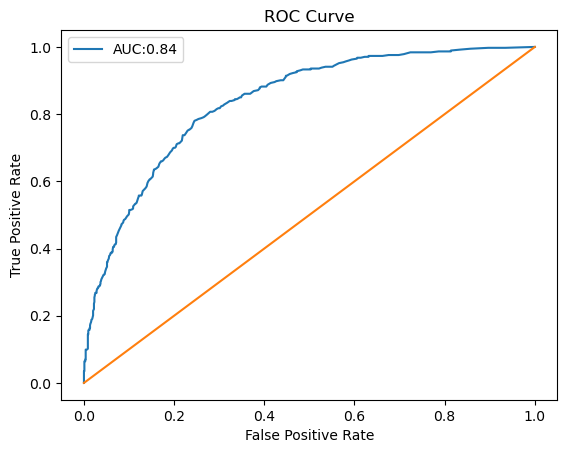

In [38]:
plt.plot(fpr_rf, tpr_rf, label=f'AUC:{roc_auc_rf:.2f}')
plt.plot([0,1],[0,1])
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## 6. MODEL COMPARISON

In [21]:
# performance of models
results = pd.DataFrame({
    "Model": ["Baseline", "Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, pred_log),
        accuracy_score(y_test, pred_rf)
    ]
})

results

,Model,Accuracy
0,Baseline,0.735273
1,Logistic Regression,0.810504
2,Random Forest,0.796309


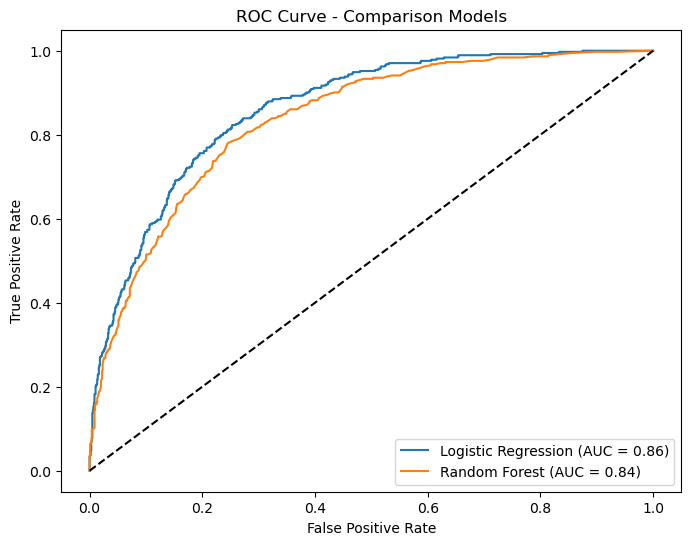

In [45]:
# ROC
plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_log:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve - Comparison Models')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
# plt.grid()
plt.show()

## 7. BUSINESS INSIGHT

In [46]:
# quais atributos mais influenciam predições?
rf_model.feature_importances_

array([0.02409931, 0.01820831, 0.02068772, 0.01747847, 0.12651194,
       0.00437197, 0.01960314, 0.02244502, 0.04414486, 0.02350694,
       0.01844195, 0.03321291, 0.014225  , 0.01482166, 0.07513375,
       0.02400951, 0.04481228, 0.14583414, 0.1453979 , 0.13804738,
       0.02500586])

In [47]:
feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)
feat_imp

gender              0.024099
SeniorCitizen       0.018208
Partner             0.020688
Dependents          0.017478
tenure              0.126512
PhoneService        0.004372
MultipleLines       0.019603
InternetService     0.022445
OnlineSecurity      0.044145
OnlineBackup        0.023507
DeviceProtection    0.018442
TechSupport         0.033213
StreamingTV         0.014225
StreamingMovies     0.014822
Contract            0.075134
PaperlessBilling    0.024010
PaymentMethod       0.044812
MonthlyCharges      0.145834
TotalCharges        0.145398
AvgCharges          0.138047
NewCustomer         0.025006
dtype: float64

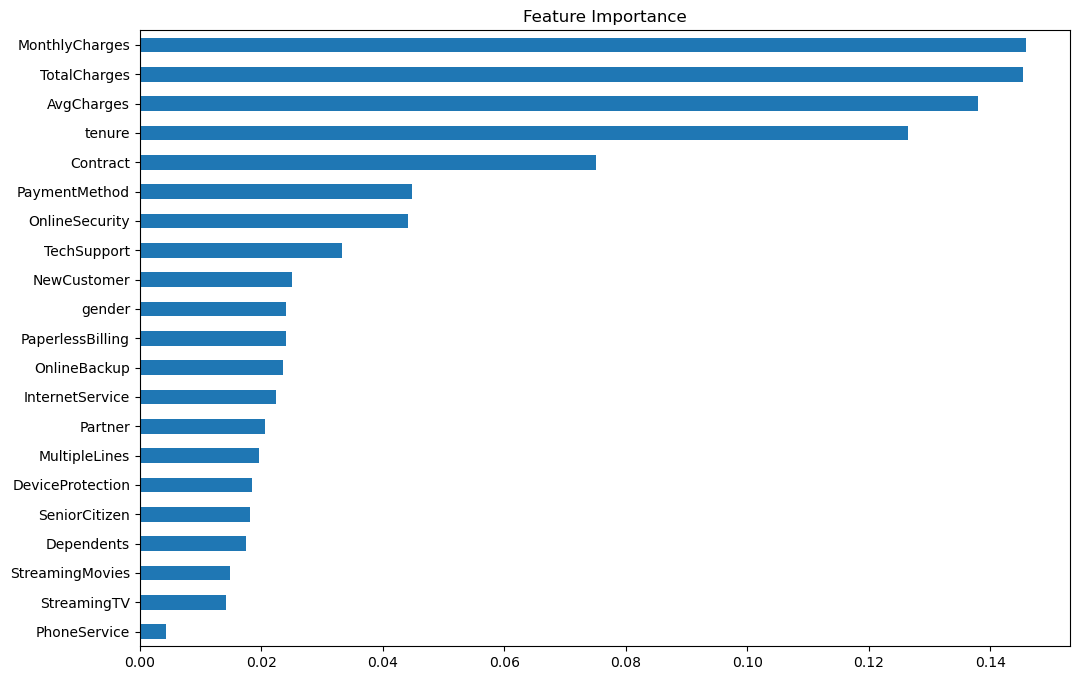

In [48]:
feat_imp.sort_values().plot(
    kind='barh',
    figsize=(12,8)
)
plt.title('Feature Importance')
plt.show()

## 8. MODEL EXPORT

In [ ]:
# model
joblib.dump(log_model, Path.cwd().parent/'src/models/churn_model.pkl')

In [ ]:
# scaler
joblib.dump(scaler, Path.cwd().parent/'src/models/scaler.pkl')

In [ ]:
# encoders
joblib.dump(encoders, Path.cwd().parent/'src/models/encoders.pkl')